## Redes Neuronales Densas (DNN)

Usa MNIST para clasificación básica.
Carga los datos, normaliza las imágenes, las aplana y construye una red densa simple con Keras/TensorFlow.
La idea acá es mostrar el caso más básico de Deep Learning.

Paso a paso
Primero cargamos imágenes de dígitos escritos a mano.

Luego normalizamos los píxeles para que la red trabaje mejor.

Después definimos una CNN simple: una capa convolucional para detectar patrones, una capa de pooling para reducir dimensiones, una capa flatten para convertir todo en un vector y, finalmente, capas densas para clasificar el
dígito entre 0 y 9.

Luego compilamos el modelo, indicando cómo aprenderá, qué error medirá y qué métrica observaremos.

Por último, lo entrenamos durante dos épocas.

In [40]:
import tensorflow as tf # TensorFlow una de las herramientas más usadas para construir y entrenar modelos de deep learning.
from tensorflow.keras import layers, models # layers: para crear las capas de la red neuronal
                                            # models: para definir la estructura completa del modelo
from tensorflow.keras.datasets import mnist # dataset MNIST, que contiene imágenes de dígitos escritos a mano del 0 al 9


# carga el dataset MNIST y lo divide en dos partes
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Divide todos los valores de los píxeles del conjunto de entrenamiento por 255.0.
# ¿Por qué? Porque las imágenes vienen con valores entre 0 y 255, y al dividirlas quedan entre 0 y 1.
X_train = X_train / 255.0
X_test = X_test / 255.0

# modelo CNN simple
model = models.Sequential([ # Definir una red neuronal usando Sequential, que significa que las capas se apilan una después de otra, en secuencia.
    layers.Reshape((28,28,1), input_shape=(28,28)), # Esta capa cambia la forma de cada imagen.
    layers.Conv2D(32, (3,3), activation='relu'), # Esta es la primera capa convolucional.
                                                 # Aplica 32 filtros, cada filtro tiene tamaño 3x3,
                                                 # recorre la imagen buscando patrones como bordes, formas o trazos
                                                 # activation='relu' agrega no linealidad.
                                                 # ReLU devuelve: el mismo valor si es positivo, 0 si es negativo
    layers.MaxPooling2D((2,2)), # Esta capa reduce el tamaño de la imagen procesada.
    layers.Flatten(),           # Convierte la salida de las capas anteriores en un solo vector unidimensional.
    layers.Dense(64, activation='relu'), # Esta es una capa densa o completamente conectada.
                                         # Tiene 64 neuronas y usa activación ReLU.
                                         # Aquí la red combina las características extraídas por la CNN para empezar a decidir qué número está viendo.
    layers.Dense(10, activation='softmax') # Esta es la capa de salida. Tiene 10 neuronas, una por cada clase posible:
                                           # 0, 1, 2, ..., 9 . softmax convierte la salida en probabilidades.
])

# Esta parte configura cómo va a aprender la red.
model.compile(optimizer='adam',     # Define el optimizador. Adam es uno de los más usados porque ajusta bien los pesos y suele converger rápido.
              loss='sparse_categorical_crossentropy', # Define la función de pérdida.
                                                      # Se usa porque: es un problema de clasificación multiclase
                                                      # las etiquetas están como enteros (0, 1, 2, etc.), no como vectores one-hot
              metrics=['accuracy']) # Indica que durante el entrenamiento quieres ver la métrica de exactitud, es decir, el porcentaje de predicciones correctas.
# Esta línea entrena el modelo usando los datos de entrenamiento.
model.fit(X_train, y_train, epochs=2)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9518 - loss: 0.1630
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9822 - loss: 0.0572


Este script carga imágenes de dígitos, construye una CNN sencilla y la entrena para reconocer números escritos a mano.

¿Qué tan bien funciona el modelo con datos nuevos?

In [41]:
# evaluar el rendimiento del modelo con datos que no se usaron durante el entrenamiento.
loss, accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9822 - loss: 0.0538


Progreso del proceso de evaluación.

Significa:
* 313/313 → se evaluaron 313 batches de datos de prueba
* 3s → tardó aproximadamente 3 segundos
* 10ms/step → cada batch tardó 10 milisegundos

Y muestra un promedio aproximado mientras evalúa:
* accuracy ≈ 0.9774 → 97.74% de aciertos
* loss ≈ 0.0643 → error promedio

In [42]:
print("Loss:", loss)
print("Accuracy:", accuracy)

Loss: 0.05383452773094177
Accuracy: 0.982200026512146


Para MNIST este resultado es muy bueno para una CNN tan pequeña.

Una CNN básica suele lograr: 97% - 99%

Para este caso se obtuvo: Accuracy = 98.26%

Eso significa que el modelo reconoce correctamente aprox. 9826 de cada 10000 imágenes.

Entrenamos la red con imágenes de entrenamiento.
Luego le mostramos imágenes que nunca había visto.
El modelo logró reconocer correctamente el 98% de los dígitos.

In [43]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_5 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041,440 (3.97 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 694,294 (2.65 MB)

capa → cómo cambia el tamaño de los datos → cuántos parámetros aprende

**reshape (Reshape) → (None, 28, 28, 1) → 0**

Reorganiza cada imagen de 28×28 para que tenga un canal (escala de grises). No aprende pesos.

**conv2d (Conv2D) → (None, 26, 26, 32) → 320**

Aplica 32 filtros de 3×3 para detectar patrones simples (bordes/trazos). Genera 32 mapas de características y aprende 320 pesos.

**max_pooling2d (MaxPooling2D) → (None, 13, 13, 32) → 0**

Reduce el tamaño de los mapas de 26×26 a 13×13 para simplificar la información. No aprende pesos.

**flatten (Flatten) → (None, 5408) → 0**

Convierte los mapas 13×13×32 en un vector de 5408 valores para poder conectarlo con capas densas.

**dense (Dense) → (None, 64) → 346,176**

Capa totalmente conectada con 64 neuronas que combina las características detectadas. Aprende 346,176 pesos.

**dense_1 (Dense) → (None, 10) → 650**

Capa de salida con 10 neuronas, una para cada dígito 0–9. Devuelve probabilidades de cada clase.

<hr>

Resumen simple:

* Conv2D → detecta patrones en la imagen
* Pooling → reduce el tamaño
* Flatten → convierte todo en un vector
* Dense → toma la decisión final (clasificación)


## CNN — clasificación de imágenes con MNIST

Primero cargamos imágenes de números escritos a mano.
Luego las normalizamos.
Después construimos una CNN pequeña que detecta patrones en la imagen, reduce tamaño, aplana la información y finalmente decide qué número es.
Luego entrenamos el modelo y lo evaluamos con imágenes nuevas para medir qué tan bien generaliza.

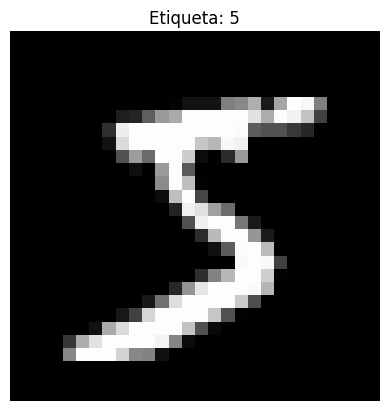

Epoch 1/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9316 - loss: 0.2319 - val_accuracy: 0.9807 - val_loss: 0.0796
Epoch 2/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9771 - loss: 0.0789 - val_accuracy: 0.9848 - val_loss: 0.0570
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9808 - loss: 0.0613
Accuracy en test: 0.9807999730110168


In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist # mnist: dataset de dígitos escritos a mano
import matplotlib.pyplot as plt

# Cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Mostrar una imagen
plt.imshow(X_train[0], cmap="gray") # primera imagen, la muestra en escala de grises
plt.title(f"Etiqueta: {y_train[0]}") # muestra la etiqueta real
plt.axis("off")
plt.show()

# Modelo CNN simple
model = models.Sequential([
    # Reorganiza cada imagen de 28x28 para agregar 1 canal.
    # Queda con forma (28, 28, 1), porque es una imagen en escala de grises.
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),

    # Capa convolucional:
    # aplica 16 filtros de tamaño 3x3 para detectar patrones simples
    # como bordes, líneas o trazos dentro de la imagen.
    # ReLU introduce no linealidad.
    layers.Conv2D(16, (3, 3), activation="relu"),

    # Capa de pooling:
    # reduce el tamaño de los mapas de características usando ventanas 2x2.
    # Esto disminuye la cantidad de información a procesar y conserva lo más importante.
    layers.MaxPooling2D((2, 2)),

    # Convierte la salida de las capas anteriores en un vector de una dimensión.
    # Esto permite conectar la parte convolucional con las capas densas.
    layers.Flatten(),

    # Capa densa oculta con 32 neuronas.
    # Aquí la red combina las características detectadas para apoyar la clasificación.
    layers.Dense(32, activation="relu"),

    # Capa de salida con 10 neuronas, una por cada clase (dígitos del 0 al 9).
    # Softmax convierte la salida en probabilidades para cada número.
    layers.Dense(10, activation="softmax")
])

# Esta parte configura cómo va a aprender la red.
model.compile(optimizer="adam", # optimizer="adam" → algoritmo que ajusta los pesos
              loss="sparse_categorical_crossentropy", # función de pérdida para clasificación multiclase con etiquetas enteras
              metrics=["accuracy"]) # metrics=["accuracy"] → quieres medir porcentaje de aciertos

# Entrenar
model.fit(X_train, y_train, epochs=2, validation_split=0.1) # epochs=2 → recorre el conjunto 2 veces
                                                            # validation_split=0.1 → separa automáticamente el 10% del entrenamiento para validació

# Evaluar el modelo con el conjunto de test, que no usó durante el entrenamiento.
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy en test:", acc)

**Época 1**

* El modelo vio todas las imágenes de entrenamiento por primera vez.
* Empezó a aprender patrones básicos de los números (líneas, curvas, formas).
* Logró 86.8% de aciertos en entrenamiento.

En validación alcanzó 97.7%, lo que indica que ya estaba reconociendo bien muchos dígitos.

En esta etapa el modelo está aprendiendo las reglas básicas del problema.

**Época 2**

* El modelo volvió a recorrer todo el dataset otra vez.
* Ajustó mejor los pesos de la red usando el error de la época anterior.
* La precisión de entrenamiento subió a 97.4%.
* La validación también mejoró a 98.2%.

Aquí el modelo refina lo que aprendió y comete menos errores.

Resultado final (test)

Cuando se probó con imágenes nuevas:

Accuracy ≈ 97.6%

Es decir, el modelo reconoce correctamente aprox. 98 de cada 100 números.

En la primera época la red ya aprende bastante, pero todavía comete varios errores.
En la segunda época mejora claramente: sube la exactitud y baja la pérdida.
Finalmente, al probarla con imágenes que nunca vio, logra cerca de un 97.7% de acierto.”

Época 1: el modelo aprende a reconocer los números.

Época 2: el modelo mejora y corrige errores.

Test: comprobamos qué tan bien funciona con datos nuevos.

## RNN / LSTM — predicción simple de serie temporal

Crea una serie temporal senoidal, entrena una LSTM para predecir el siguiente valor y compara la predicción con los valores reales.

In [45]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Aquí se construye una serie artificial basada en la función seno.
x = np.linspace(0, 100, 500) # Genera 500 valores entre 0 y 100.
serie = np.sin(x) # A cada uno de esos valores le aplica seno, generando una curva ondulada.

# Ese bloque arma pares de entrada-salida para enseñar al modelo a predecir el siguiente valor de una serie temporal.
""" Lo hace por una razón muy concreta: para transformar una serie continua en ejemplos de entrenamiento que la red pueda aprender.
Las redes neuronales (como una LSTM) no aprenden directamente de una serie completa, sino de muchos ejemplos entrada → salida.
Este bloque crea justamente esos ejemplos.
"""
window = 10
X, y = [], []
for i in range(len(serie) - window):
    X.append(serie[i:i+window])
    y.append(serie[i+window])

# Convierte las listas en arreglos de NumPy para poder trabajar con ellas en el modelo.
X = np.array(X)
y = np.array(y)

# Reformar para LSTM: [muestras, pasos de tiempo, features]
X = X.reshape((X.shape[0], X.shape[1], 1))
"""En este caso:
muestras: cantidad de ejemplos
pasos de tiempo: 10
features: 1, porque en cada instante solo hay un valor numérico
Entonces cada entrada queda como una secuencia de 10 pasos, con 1 variable por paso.
"""

# Modelo LSTM
model = models.Sequential([
    # Es la capa principal. usa una red LSTM, tiene 32 unidades,  recibe secuencias de longitud 10
    # cada paso tiene 1 característica
    # La LSTM está diseñada para captar patrones en secuencias, o sea, relaciones entre valores anteriores y futuros.
    layers.LSTM(32, input_shape=(window, 1)),
    # La salida es un único número.
    # Eso tiene sentido porque el objetivo es predecir el siguiente valor de la serie.
    layers.Dense(1)
])
"""
Aquí se define cómo va a aprender.
optimizer="adam": Adam ajusta los pesos de la red.
loss="mse": Usa error cuadrático medio, porque este no es un problema de clasificación, sino de predicción numérica.
"""
model.compile(optimizer="adam", loss="mse")

"""
El modelo entrena con:
X: ventanas de 10 valores
y: valor siguiente real
epochs=5
Recorre todo el dataset 5 veces.
Con cada época ajusta los pesos para mejorar sus predicciones.
"""
model.fit(X, y, epochs=5, verbose=1)

# Predicción
pred = model.predict(X[:50]) # Le pides al modelo que prediga los primeros 50 casos.


Epoch 1/5


d:\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5952
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4045 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3138 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2430 
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1765 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


En cada época la red ajustó sus pesos para predecir mejor el siguiente valor de la serie.
Como vemos, la pérdida fue bajando desde 0.46 hasta 0.1, lo que indica que el modelo aprendió bastante bien el patrón temporal.

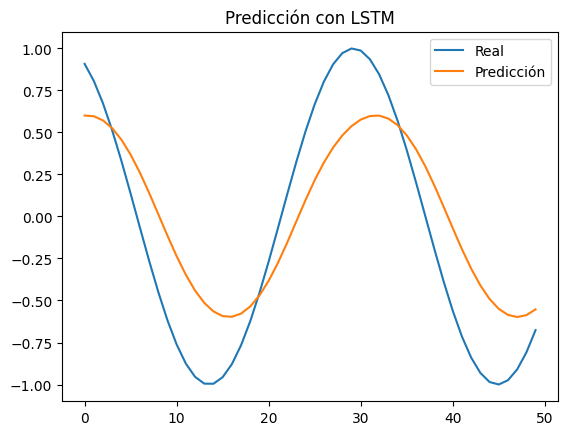

In [46]:
# Graficar resultados
plt.plot(y[:50], label="Real")
plt.plot(pred, label="Predicción")
plt.legend()
plt.title("Predicción con LSTM")
plt.show()

La línea azul es la serie real y la naranja es lo que predice la red.
Vemos que la red no es perfecta, pero logra seguir bastante bien el patrón de la señal.
Esto demuestra que las LSTM pueden aprender dependencias temporales usando valores anteriores.

## Autoencoder — compresión / reconstrucción de imágenes

Aquí la red no clasifica ni predice una serie, sino que intenta reconstruir la misma imagen de entrada.

Este script entrena una red para comprimir imágenes de dígitos y luego reconstruirlas, comparando la imagen original con la reconstruida.

El autoencoder aprende a guardar una versión resumida de la imagen en solo 32 valores, y luego intenta reconstruirla.
Si la reconstrucción se parece mucho a la original, significa que logró capturar la información importante.

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Cargar datos
(X_train, _), (X_test, _) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar imágenes: Esto se hace porque este autoencoder usa capas densas, no convolucionales.
X_train = X_train.reshape((-1, 28*28))
X_test = X_test.reshape((-1, 28*28))

# Definir dimensiones
input_dim = 28 * 28 # input_dim = 784 → tamaño de entrada
encoding_dim = 32 # encoding_dim = 32 → tamaño de la representación comprimida
# La red toma una imagen de 784 valores y la comprime a 32 valores.
# Eso fuerza al modelo a conservar solo la información más importante.

# Construcción del autoencoder
input_img = layers.Input(shape=(input_dim,)) # La entrada es un vector de 784 números.
encoded = layers.Dense(encoding_dim, activation='relu')(input_img) # Esta es la parte encoder.
# Toma la imagen original y la comprime a un vector de tamaño 32.
# La red intenta guardar una versión resumida de la imagen.

# Esta es la parte decoder.
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)
# Toma la representación comprimida de 32 valores y trata de reconstruir la imagen original de 784 píxeles.
# La activación sigmoid se usa porque los píxeles están normalizados entre 0 y 1.

# Aquí se define el modelo completo
autoencoder = models.Model(input_img, decoded) # entra la imagen original, sale la imagen reconstruida
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
# La pérdida mide qué tan distinta es la reconstrucción respecto a la imagen original.

# Entrenar
autoencoder.fit(X_train, X_train, epochs=5, batch_size=256, shuffle=True, validation_split=0.1)
# epochs=5 → recorre los datos 5 veces
# batch_size=256 → procesa 256 imágenes por lote
# shuffle=True → mezcla los datos
# validation_split=0.1 → reserva 10% para validación

# Reconstrucción
decoded_imgs = autoencoder.predict(X_test[:5])
# Tomas 5 imágenes de test y le pides al modelo que las reconstruya.
# La salida será una versión reconstruida de esas imágenes.



Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2858 - val_loss: 0.1948
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1751 - val_loss: 0.1589
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1496 - val_loss: 0.1396
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1335 - val_loss: 0.1268
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1227 - val_loss: 0.1179
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


El modelo oo que intenta hacer es:
* tomar una imagen
* comprimirla
* reconstruirla

Entonces la métrica importante es la pérdida, que mide qué tan distinta quedó la imagen reconstruida respecto a la original.

En simple
* loss: error en entrenamiento
* val_loss: error en validación

Mientras ambas bajen, es buena señal.

En cada época el autoencoder fue mejorando su capacidad de reconstruir la imagen original a partir de una versión comprimida.

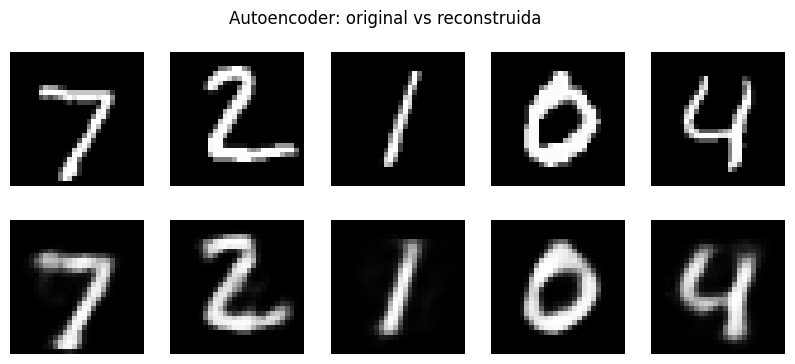

In [48]:
# Mostrar originales vs reconstruidas
plt.figure(figsize=(10, 4))
for i in range(5):
    # original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruida
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Autoencoder: original vs reconstruida")
plt.show()

* Fila superior → imágenes originales
* Fila inferior → imágenes reconstruidas

Se puede ver que:
* las reconstruidas se parecen bastante a las originales
* pero aparecen más borrosas

Esto pasa porque el autoencoder:
* comprimió 784 valores → 32
* luego intentó reconstruirlos

Entonces pierde algo de detalle, pero mantiene la estructura del número.

## Transformer / modelo preentrenado — análisis de sentimiento

Este script usa un modelo Transformer preentrenado para analizar el sentimiento de varios textos y clasificarlos como positivos o negativos.

Aquí no entrenamos el modelo. Usamos un Transformer ya entrenado que entiende lenguaje natural y puede analizar el sentimiento de un texto.”

In [60]:
# Instala la librería Transformers de Hugging Face.
!pip -q install transformers

from transformers import pipeline # pipeline es una herramienta que simplifica el uso de modelos de IA.
# En vez de construir el modelo paso a paso, pipeline permite hacer algo como: tarea → modelo → resultado

# Aquí se crea un modelo para análisis de sentimiento.
classifier = pipeline("sentiment-analysis")
# Esto hace automáticamente:
# descarga un modelo Transformer preentrenado
# lo carga en memoria
# lo prepara para clasificar textos

# Textos a analizar
textos = [
    "Me encantó esta clase de redes neuronales",
    "Este contenido me confundió bastante",
    "La explicación estuvo clara y útil"
]

# Ejecutar el modelo
resultados = classifier(textos)
# Aquí el modelo analiza cada frase.
# Internamente hace varias cosas:
# * convierte el texto en tokens
# * aplica el modelo Transformer
# * calcula probabilidades de cada clase

# Recorre cada texto junto con su resultado.
for texto, resultado in zip(textos, resultados):
    print(f"Texto: {texto}")
    print(f"Resultado: {resultado}")
    print("-" * 50)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Texto: Me encantó esta clase de redes neuronales
Resultado: {'label': 'POSITIVE', 'score': 0.9161191582679749}
--------------------------------------------------
Texto: Este contenido me confundió bastante
Resultado: {'label': 'POSITIVE', 'score': 0.8559314012527466}
--------------------------------------------------
Texto: La explicación estuvo clara y útil
Resultado: {'label': 'POSITIVE', 'score': 0.6987242698669434}
--------------------------------------------------


* el pipeline funcionó técnicamente, pero el modelo no es el más adecuado para estos textos en español.

En IA no basta con que el modelo corra. También hay que verificar si el modelo es adecuado para el tipo de dato y el idioma.

| Modelo      | Tipo de dato                |
| ----------- | --------------------------- |
| CNN         | Imágenes                    |
| LSTM        | Series temporales           |
| Autoencoder | Compresión / representación |
| Transformer | Lenguaje natural            |


**Modelo específico para español**

In [61]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis"
)

textos = [
    "Me encantó esta clase de redes neuronales",
    "Este contenido me confundió bastante",
    "La explicación estuvo clara y útil"
]

resultados = classifier(textos)

for texto, resultado in zip(textos, resultados):
    print(f"Texto: {texto}")
    print(f"Resultado: {resultado}")
    print("-" * 50)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Texto: Me encantó esta clase de redes neuronales
Resultado: {'label': 'POS', 'score': 0.9683510065078735}
--------------------------------------------------
Texto: Este contenido me confundió bastante
Resultado: {'label': 'NEG', 'score': 0.9048544764518738}
--------------------------------------------------
Texto: La explicación estuvo clara y útil
Resultado: {'label': 'POS', 'score': 0.9074024558067322}
--------------------------------------------------


Ahora usamos un modelo más adecuado para español.
Se nota porque las clasificaciones son más coherentes: detecta como positivo un comentario favorable, como negativo uno de confusión, y vuelve a clasificar como positivo una frase claramente favorable.
Además, el score indica cuánta confianza tiene el modelo en su predicción.

## PARTE 2

## **Proceso de entrenamiento en Deep Learning**

Este modelo entrena una red neuronal simple (MLP) para reconocer dígitos escritos a mano.

El dataset que usamos (digits) contiene imágenes pequeñas de números del 0 al 9.
Cada imagen es convertida en números que representan los píxeles.

La red neuronal aprende a identificar patrones en esos píxeles para responder:

“¿Este dibujo corresponde al número 0, 1, 2, … o 9?”

In [62]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1 Preparación de datos
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2 Diseño de arquitectura
model = MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, random_state=42)

# 3 Entrenamiento
model.fit(X_train, y_train)

# 4 Evaluación
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9688888888888889


Con este ejemplo pequeño ya vemos todo el flujo: cargamos datos, definimos una red, la entrenamos y la evaluamos. Y aun siendo un modelo simple, logró cerca de un 97% de precisión.

**Desafíos del Deep Learning**

1. Necesidad de datos

    Mostrar cuántos datos tienen algunos datasets famosos

In [52]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Imágenes de entrenamiento:", X_train.shape[0])
print("Imágenes de prueba:", X_test.shape[0])

Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000


ejemplos reales:

ImageNet → 14 millones de imágenes

GPT → billones de palabra

2. Recursos computacionales

    Entrenar modelos grandes requiere mucho poder computacional.

In [53]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[]

3. Interpretabilidad

    Muchas redes profundas funcionan como cajas negras.

In [54]:
import shap

4. Sobreajuste



El modelo aprende demasiado bien los datos de entrenamiento pero falla en datos nuevos.

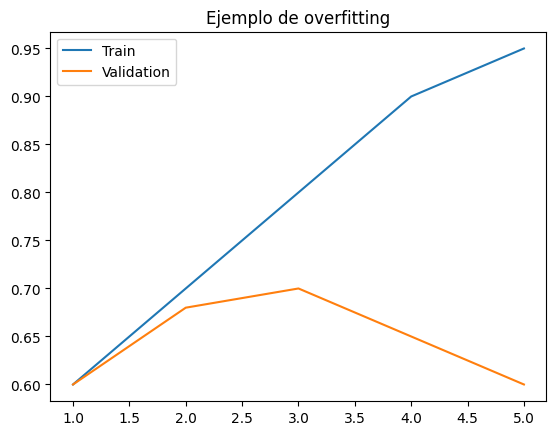

In [55]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5]
train = [0.6,0.7,0.8,0.9,0.95]
val = [0.6,0.68,0.7,0.65,0.6]

plt.plot(epochs, train, label="Train")
plt.plot(epochs, val, label="Validation")
plt.legend()
plt.title("Ejemplo de overfitting")
plt.show()

# **Demo ResNet paso a paso**

Vamos a usar ResNet50, un modelo entrenado con millones de imágenes del dataset ImageNet.

In [64]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

Aquí no estamos entrenando nada. Estamos cargando un modelo que ya fue entrenado.

In [65]:
model = ResNet50(weights="imagenet")

print("Modelo cargado")

Modelo cargado


Cargar una imagen

In [ ]:
from google.colab import files
uploaded = files.upload( )

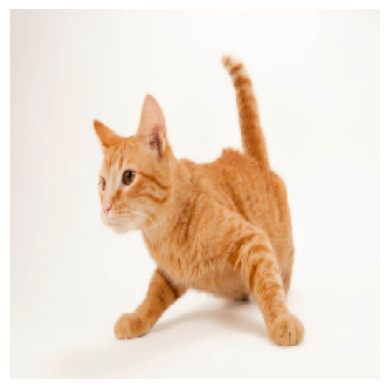

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


In [72]:
# cargar imagen subida
img = image.load_img("gato.jpg", target_size=(224, 224))
img_array = image.img_to_array(img)

# mostrar imagen
plt.imshow(img)
plt.axis("off")
plt.show()

# preparar imagen
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# predecir
preds = model.predict(img_array)

In [73]:
# mostrar predicciones
decoded = decode_predictions(preds, top=3)[0]
for _, label, prob in decoded:
    print(f"{label}: {prob:.3f}")

tiger_cat: 0.593
tabby: 0.130
tub: 0.035


**African_elephant: 0.857**

El modelo cree con 85.7% de probabilidad que la imagen corresponde a un elefante africano.

**tusker: 0.106**

Con 10.6% de probabilidad cree que podría ser un tusker, que es un elefante con colmillos prominentes.

**Indian_elephant: 0.037**

Con 3.7% de probabilidad considera que podría ser un elefante indio.